## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os 

## Helper function

In [2]:
def load_data(file_path):
    #output (N_object, N_time* n_unit (2D:5(t,l,t,w,h) or 3D:4(t,x,y,z)))
    
    # Find max number of columns first
    with open(file_path, "r") as f:
        max_cols = max(len(line.strip().split(",")) for line in f if line.strip())

    data = pd.read_csv(
        file_path,
        header=None,
        names=range(max_cols),
        engine="python"
    ).fillna(-2).astype(float).values #(N_object, N_time*n_unit (2D:5(t,l,t,w,h) or 3D:4(t,x,y,z)))

    return data

def array2dict(array,n_unit, n_minimum_valid_data):
    #output N_object : np.array(N_time, n_unit)

    # Convert array to dictionary with keys as object indices and values as time series
    dict_return = {} #N_object : (N_time, n_unit)
    for i in range(array.shape[0]): #N_object
        n_seq = array.shape[1]//n_unit #N_time
        seq_data = []
        for j in range(n_seq): #N_time
            if array[i,j*n_unit] != -2:#valid data
                seq_data.append(array[i,j*n_unit:(j+1)*n_unit].tolist()) #(N_time, n_unit)
        if len(seq_data) >= n_minimum_valid_data:
            dict_return[i] = np.array(seq_data)
    return dict_return

## Plot
def plot_2d(data,fig,ax):
    #data : N_time, 5(time, left,top,width,height)
    #time, left,top,width,height
    for i in range(4):
        ax[i//2,i%2].plot(data[:,0],data[:,i+1]) #(time, value)
    return fig, ax

def set_ax_2d(ax):
    # Enhance axis labels, titles, and ticks for better visibility
    label_font = {'fontsize': 18, 'fontweight': 'bold'}
    title_font = {'fontsize': 20, 'fontweight': 'bold'}
    tick_fontsize = 16

    ax[0,0].set_xlabel('time [s]', **label_font)
    ax[0,1].set_xlabel('time [s]', **label_font)
    ax[1,0].set_xlabel('time [s]', **label_font)
    ax[1,1].set_xlabel('time [s]', **label_font)

    ax[0,0].set_ylabel('left [px]', **label_font)
    ax[0,1].set_ylabel('top [px]', **label_font)
    ax[1,0].set_ylabel('width [px]', **label_font)
    ax[1,1].set_ylabel('height [px]', **label_font)

    ax[0,0].set_title('left', **title_font)
    ax[0,1].set_title('top', **title_font)
    ax[1,0].set_title('width', **title_font)
    ax[1,1].set_title('height', **title_font)

    for i in range(2):
        for j in range(2):
            ax[i,j].tick_params(axis='both', which='major', labelsize=tick_fontsize, width=2)
            ax[i,j].grid(True, alpha=0.3)
            for spine in ax[i,j].spines.values():
                spine.set_linewidth(2)
    return ax

def plot_3d(data,fig,ax):
    #data : N_time, 4(time, x,y,z)
    #time, x,y,z
    for i in range(3):
        ax[i].plot(data[:,0],data[:,i+1]) #(time, value)
    return fig, ax

def set_ax_3d(ax):
    # Enhance axis labels, titles, and ticks for better visibility
    label_font = {'fontsize': 18, 'fontweight': 'bold'}
    title_font = {'fontsize': 20, 'fontweight': 'bold'}
    tick_fontsize = 16  

    ax[0].set_xlabel('time [s]', **label_font)
    ax[1].set_xlabel('time [s]', **label_font)
    ax[2].set_xlabel('time [s]', **label_font)

    ax[0].set_ylabel('x [m]', **label_font)
    ax[1].set_ylabel('y [m]', **label_font)
    ax[2].set_ylabel('z [m]', **label_font)

    ax[0].set_title('x', **title_font)
    ax[1].set_title('y', **title_font)
    ax[2].set_title('z', **title_font)
    
    for i in range(3):
        ax[i].tick_params(axis='both', which='major', labelsize=tick_fontsize, width=2)
        ax[i].grid(True, alpha=0.3)
        for spine in ax[i].spines.values():
            spine.set_linewidth(2)
    return ax





## Load data

In [9]:
rootDir = r"C:\Users\kawaw\cpp\skeleton_tracking_latest\csv\realsense\human_cube_tracking"
path_2d = os.path.join(rootDir, 'saved_data_2d.csv')
path_3d = os.path.join(rootDir, 'saved_data_3d.csv')

n_unit_2d = 5
n_unit_3d = 4
n_minimum_valid_sequence = 10

data_2d = load_data(path_2d)
data_3d = load_data(path_3d)

dict_2d = array2dict(data_2d, n_unit_2d, n_minimum_valid_sequence)
dict_3d = array2dict(data_3d, n_unit_3d, n_minimum_valid_sequence)

## plot

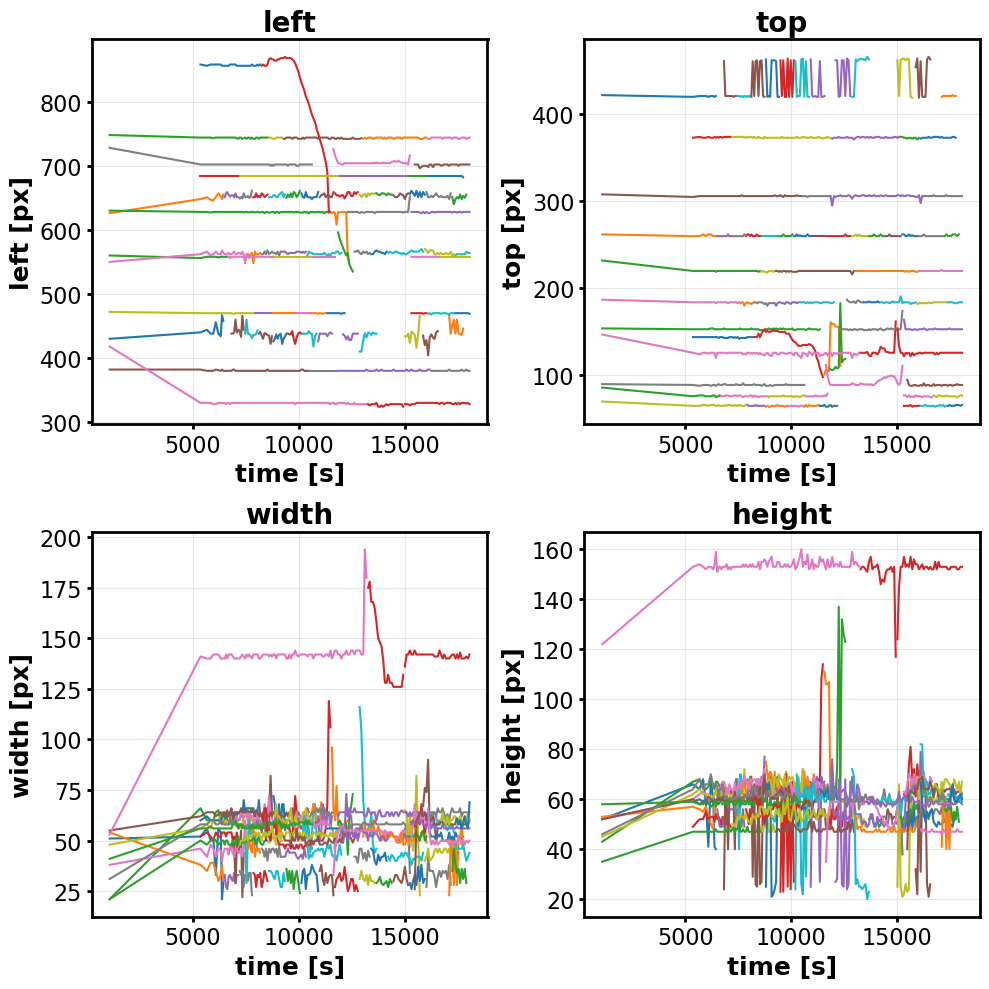

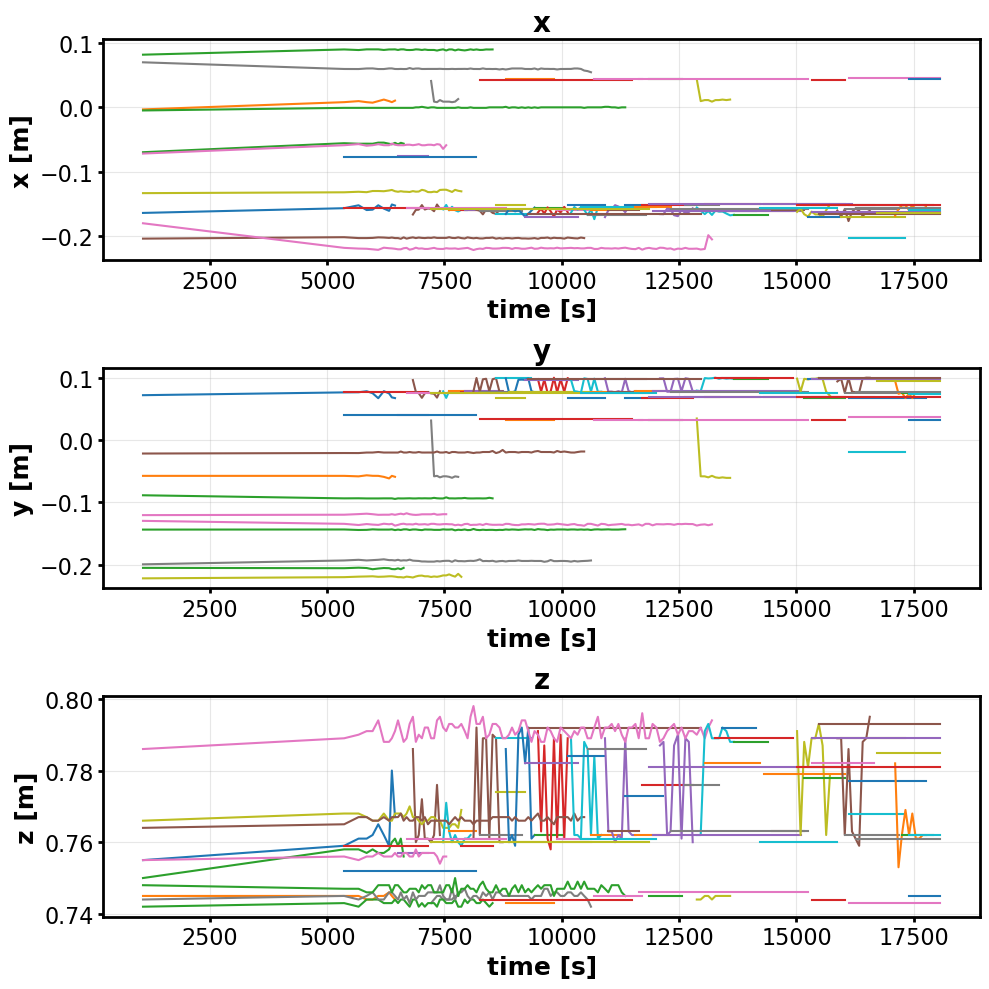

In [10]:
fig,ax = plt.subplots(2,2,figsize=(10,10))
#plot data.
for key in dict_2d.keys():
    fig,ax = plot_2d(dict_2d[key],fig,ax)
ax = set_ax_2d(ax)
plt.tight_layout()
plt.show()


fig,ax = plt.subplots(3,1,figsize=(10,10))
#plot data.
for key in dict_3d.keys():
    fig,ax = plot_3d(dict_3d[key],fig,ax)
ax = set_ax_3d(ax)
plt.tight_layout()
plt.show()
